In [1]:
# verificar a localização do interpretador adequado do python (bibliotecas, etc.)
# import sys
# print(sys.executable)

                  nome  latitude  longitude                     geometry
0  São José dos Campos -23.22370  -45.90090    POINT (-45.9009 -23.2237)
1        Fatec Jacareí -23.29521  -45.96692  POINT (-45.96692 -23.29521)
2            São Paulo -23.55050  -46.63330    POINT (-46.6333 -23.5505)


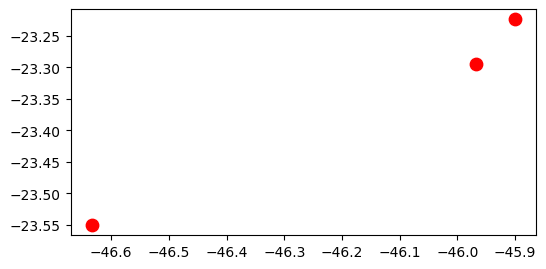

In [2]:
# Exemplificando conjuntos de pontos em mapas usando geopandas

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Criando dados simples
data = {
    "nome": ["São José dos Campos", "Fatec Jacareí",  "São Paulo"],
    "latitude": [-23.2237, -23.29521, -23.5505],
    "longitude": [-45.9009, -45.96692, -46.6333]
}

df = pd.DataFrame(data)

# Criação das geometrias apropriadas (pontos)
geometry = [Point(xy) for xy in zip(df["longitude"], df["latitude"])]

# Criando GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=geometry)

# Definindo sistema de coordenadas (WGS84 - GPS)
# Não utilizar para o cálculo de distâncias, utilizar  o EPSG 3857
gdf.set_crs(epsg=4326, inplace=True)

print(gdf)
gdf.plot(figsize=(6, 6), color="red", markersize=80)

plt.show()

In [3]:
import folium

# Criando, centralizando e definindo o zoom inicial do mapa.
mapa = folium.Map(location=[-23.29, -45.96], zoom_start=10)

# Adicionando os pontos do dataframe
for _, row in df.iterrows():
    folium.Marker( location=[row["latitude"], row["longitude"]], popup=row["nome"]).add_to(mapa)
mapa